In [11]:
# Stop warnings
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# Personal imports
sys.path.append("{}/../../../analysis_code/utils".format(os.getcwd()))
from plot_utils import plotly_template
from settings_utils import load_settings

In [2]:
main_dir = '/Users/uriel/disks/meso_shared'
project_dir = 'RetinoMaps'
subject = 'group'
format_ = '91k'

In [31]:
base_dir = os.path.abspath(os.path.join(os.getcwd(), "../../../"))
settings_path = os.path.join(base_dir, project_dir, "settings.yml")
prf_settings_path = os.path.join(base_dir, project_dir, "prf-analysis.yml")
figure_settings_path = os.path.join(base_dir, project_dir, "figure-settings.yml")
settings = load_settings([settings_path, prf_settings_path, figure_settings_path])
analysis_info = settings[0]

rois = ['iIPS', 'sIPS', 'iPCS', 'sPCS', 'mPCS']

In [4]:
cor_dir = '{}/{}/derivatives/pp_data/{}/{}/rest/partial_corr/by_hemi'.format(main_dir, project_dir, subject, format_)
cor_r_lh_fn = '{}/{}_mean_cluster_by_mmp-parcel_partial_r_concat_clean_lh.csv'.format(cor_dir, subject)
cor_r_rh_fn = '{}/{}_mean_cluster_by_mmp-parcel_partial_r_concat_clean_rh.csv'.format(cor_dir, subject)

cor_r_lh_df = pd.read_csv(cor_r_lh_fn)
cor_r_rh_df = pd.read_csv(cor_r_rh_fn)


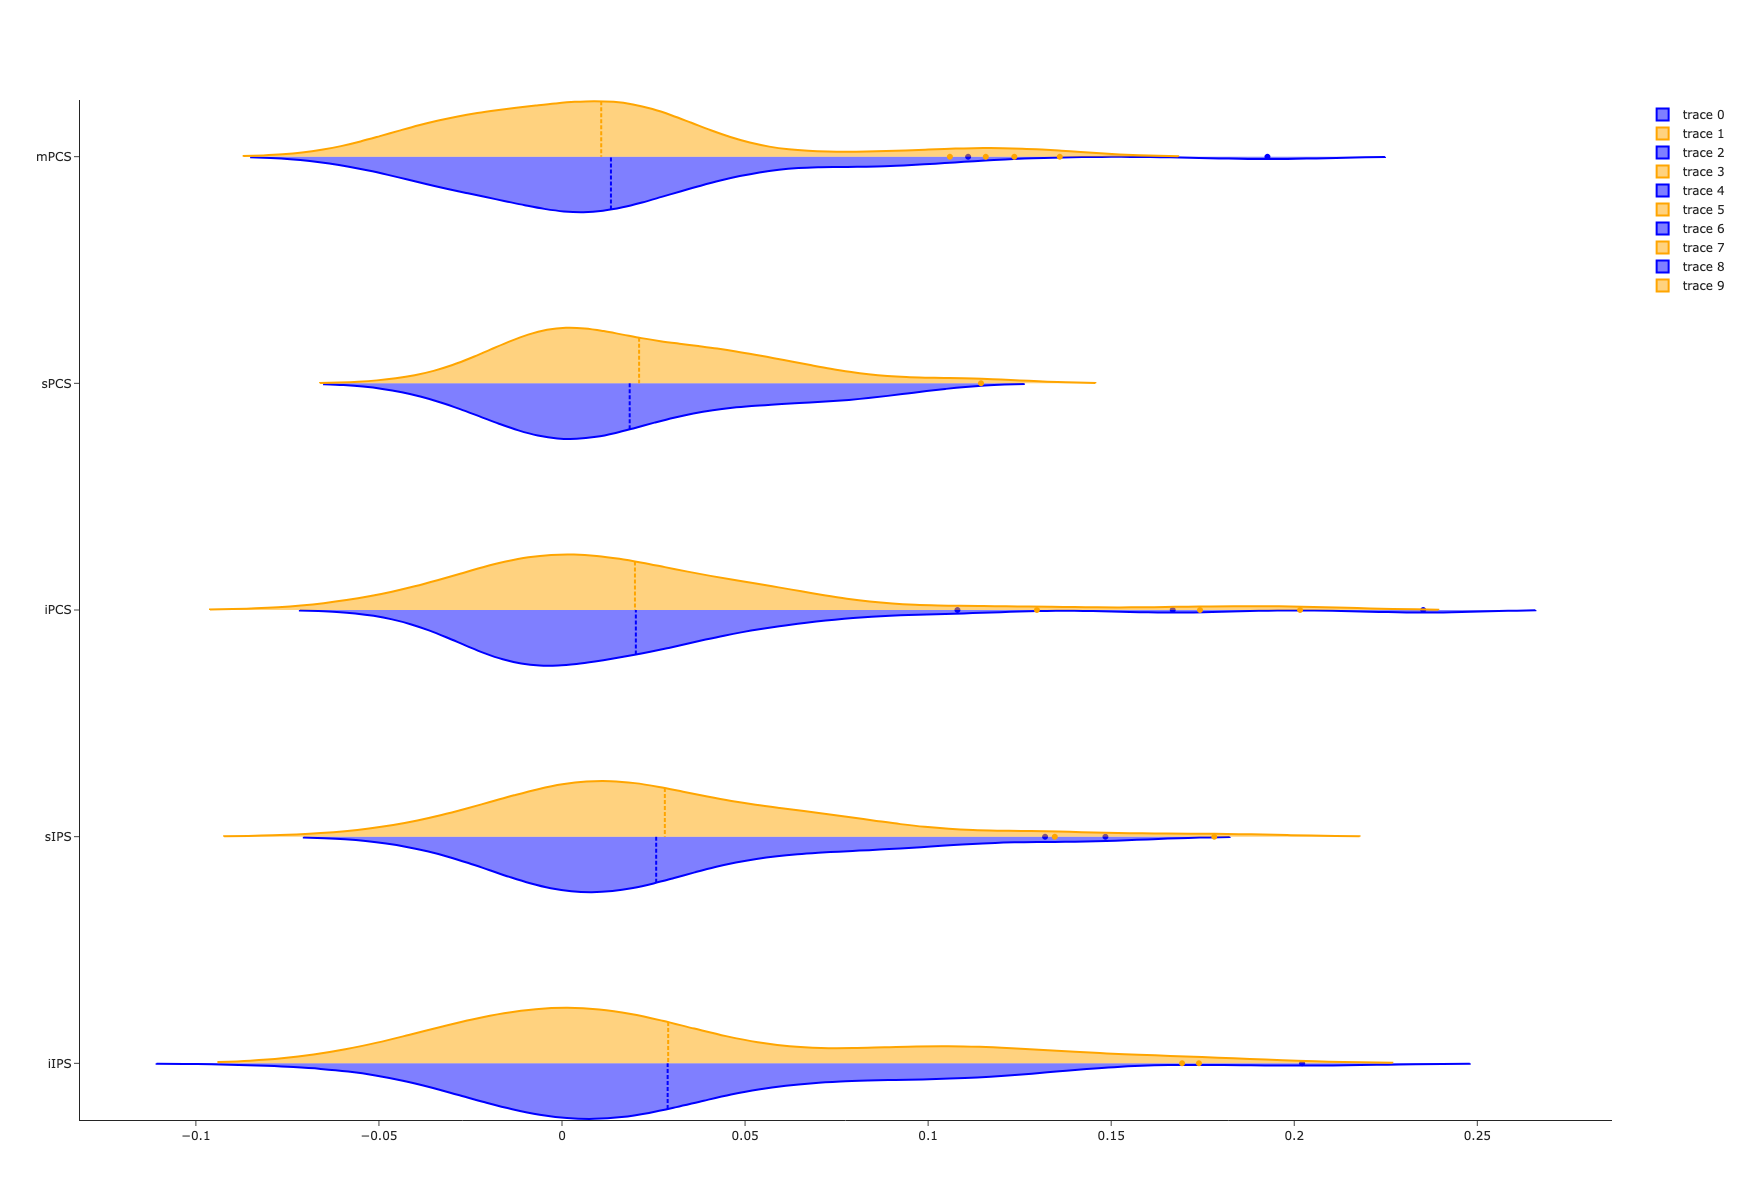

In [40]:
fig = go.Figure()

for roi_num, roi in enumerate(rois):

    roi_cor_r_lh_df = cor_r_lh_df.loc[cor_r_lh_df['Unnamed: 0'] == roi]
    roi_cor_r_rh_df = cor_r_rh_df.loc[cor_r_rh_df['Unnamed: 0'] == roi]

    lh_values = roi_cor_r_lh_df.drop(columns='Unnamed: 0').iloc[0].to_numpy()
    rh_values = roi_cor_r_rh_df.drop(columns='Unnamed: 0').iloc[0].to_numpy()

    fig.add_trace(
        go.Violin(
            x=lh_values,
            y=[roi] * len(lh_values),
            side='negative',
            line_color='blue',
            orientation='h'
        )
    )

    fig.add_trace(
        go.Violin(
            x=rh_values,
            y=[roi] * len(rh_values),
            side='positive',
            line_color='orange',
            orientation='h'
        )
    )

fig.update_traces(meanline_visible=True)

fig.update_layout(
    template='simple_white',
    height=1200,
    width=1400,
    violinmode='overlay'
)

fig.show()

In [41]:
cor_r_lh_df

,Unnamed: 0,SCEF,p32pr,24dv,FEF,i6-8,6a,6d,6mp,6ma,...,LO1,LO2,LO3,V3A,V3B,V3CD,V3,V4,V2,V1
0,mPCS,NaN,NaN,NaN,0.078002,-0.024935,0.003245,0.010530,0.110923,0.088894,...,0.034002,0.029248,-0.031711,0.014625,0.071846,-0.052820,-0.010027,-0.037228,0.010798,0.035758
1,sPCS,0.093596,0.054600,0.050674,NaN,NaN,NaN,NaN,NaN,NaN,...,0.004324,-0.013137,0.017347,0.007280,-0.004598,0.007964,-0.010560,-0.009701,-0.025104,0.027295
2,iPCS,0.235218,0.050264,-0.014319,0.108011,-0.012331,0.067931,0.064253,-0.010106,0.022880,...,-0.013680,-0.027590,0.005871,-0.008433,0.008407,-0.014237,-0.016163,-0.040946,0.029876,0.005138
3,sIPS,-0.012119,0.021308,-0.036599,0.075858,-0.035298,0.103452,0.031193,0.013397,0.030467,...,0.004233,0.012525,0.036450,0.027529,0.006563,0.011445,0.001455,0.019348,-0.008021,-0.004087
4,iIPS,-0.002234,0.011220,0.014423,0.028431,-0.019693,0.081618,0.032199,-0.028122,0.000003,...,0.026690,-0.064948,0.057101,0.082863,0.121367,0.114848,-0.016783,0.012215,-0.021309,0.014471
5,hMT+,-0.032306,-0.030287,-0.000226,-0.006573,-0.004306,-0.021926,-0.000119,0.046427,0.023584,...,0.062855,0.122252,0.106210,0.056775,0.016995,-0.020478,0.022606,0.051033,-0.001249,-0.022789
6,VO,-0.010132,0.015296,0.008908,-0.016130,0.032220,-0.008301,0.002441,0.015834,0.016158,...,0.046464,0.141350,0.010831,-0.020142,0.029218,0.059019,0.008562,0.159302,0.042408,0.045081
7,LO,0.036871,-0.018607,-0.030862,0.009604,0.008792,-0.009908,-0.014864,0.011567,-0.024239,...,NaN,NaN,NaN,0.074923,0.040567,0.209447,0.045684,0.117005,0.006030,-0.004409
8,V3AB,0.001542,-0.023448,-0.015754,0.014494,-0.020805,-0.007602,-0.010027,-0.001262,0.014422,...,0.070830,0.060015,0.094343,NaN,NaN,NaN,0.118157,0.106822,0.072702,0.027092
9,V3,-0.012292,-0.020712,-0.025129,-0.002550,0.028834,0.007607,0.014587,0.001716,0.013303,...,0.102297,0.116054,-0.037020,0.094200,0.051359,0.060618,NaN,NaN,0.249141,0.075222
